# Clustering Analysis on Patient Dataset
## Complete Guide for KMeans, DBSCAN, and Hierarchical Clustering

This notebook provides a comprehensive step-by-step guide for performing cluster analysis on patient data using three major clustering algorithms: KMeans, DBSCAN, and Hierarchical Clustering.

Before digging into the analysis, we import the dependency libraries: 

In [39]:
!pip install scikit-learn scipy pandas matplotlib seaborn umap-learn

## Loading and Exploration

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist
from pathlib import Path

# Load dataset
notebook_dir = Path().resolve()
FEATURE_PATH = notebook_dir.parents[1]  / "1" / "Features" 
PATIENT_PROFILES_NAME = "patient_profiles.csv"

df = pd.read_csv(FEATURE_PATH / PATIENT_PROFILES_NAME)

print(f"Dataset: {df.shape[0]} patients, {df.shape[1]} features")
print(f"Missing values: {df.isnull().sum().sum()}")

Dataset: 4761 patients, 26 features
Missing values: 0


## Preprocessing
### Feature Selection for Clustering

In [41]:
subset_1_clinical_core = [
    'oxygen_saturation',
    'heart_rate',
    'respiratory_rate',
    'temperature',
    'disease_burden_score',
    'exam_abnormality_score',
    'procedure_complexity',
    'age'
]

subset_2_risk_stratification = [
    'high_risk_patient',
    'complex_patient',
    'ecg_abnormality_score',
    'cardiac_remodeling_score',
    'disease_burden_score',
    'testing_intensity',
    'age'
]

subset_3_compact = [
    'oxygen_saturation',
    'disease_burden_score',
    'procedure_complexity',
    'high_risk_patient',
    'age'
]

subset_4_vital_signs = [
    'oxygen_saturation',
    'heart_rate',
    'respiratory_rate',
    'bp_systolic',
    'temperature'
]

subset_5_patient_complexity = [
    'complex_patient',
    'high_risk_patient',
    'disease_burden_score',
    'procedure_complexity',
    'total_procedures',
    'testing_intensity'
]

feature_subsets = {
    'clinical_core': subset_1_clinical_core,
    'risk_stratification': subset_2_risk_stratification,
    'compact': subset_3_compact,
    'vital_signs': subset_4_vital_signs,
    'patient_complexity': subset_5_patient_complexity
}


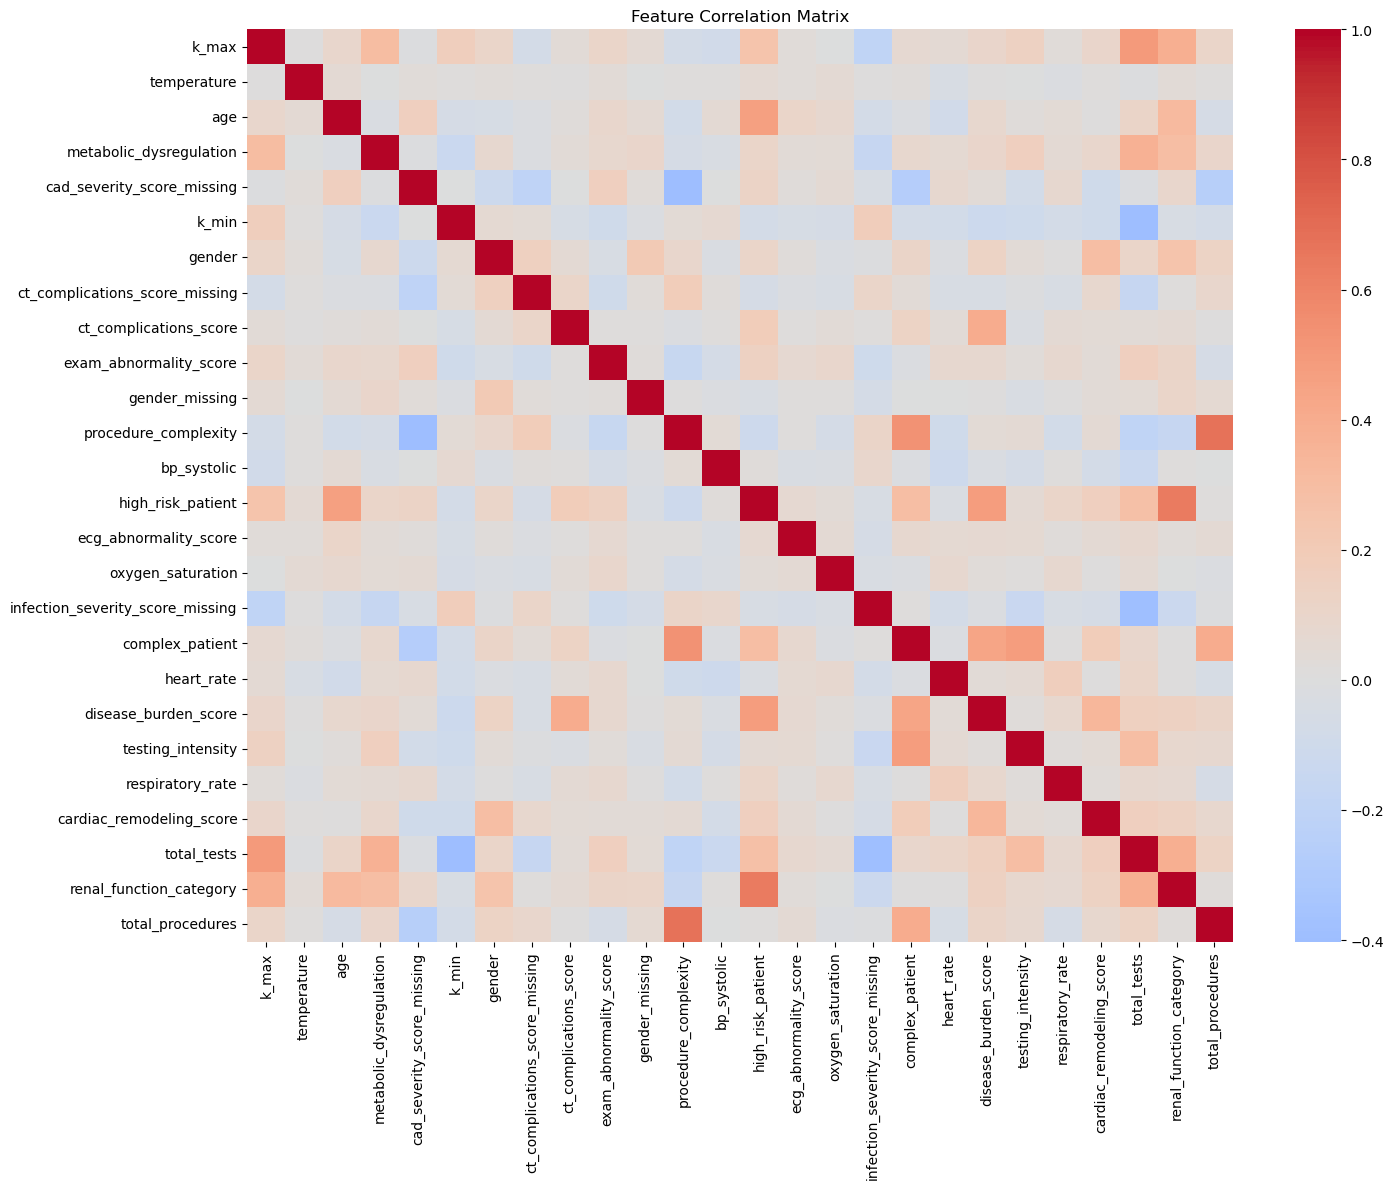

In [42]:
# Remove identifier
features_for_clustering = df.copy()

# Check correlations
correlation_matrix = features_for_clustering.corr()
plt.figure(figsize=(15, 12))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

### Standardization

In [43]:
# Standardization (essential for distance-based clustering)
# scaler = RobustScaler()
# X_scaled = scaler.fit_transform(features_for_clustering)

# # DataFrame with scaled data
# X_scaled_df = pd.DataFrame(X_scaled, columns=features_for_clustering.columns)

# print("Mean after scaling:", X_scaled.mean(axis=0).round(3))
# print("Std after scaling:", X_scaled.std(axis=0).round(3))

from sklearn.compose import ColumnTransformer


binary_cols = []
continuous_cols = []

for col in features_for_clustering.columns:
    unique_vals = features_for_clustering[col].nunique()
    if unique_vals <= 2:
        binary_cols.append(col)
    else:
        continuous_cols.append(col)

print(f"\nBinary features: {len(binary_cols)}")
print(binary_cols[:10])
print(f"\nContinuous features: {len(continuous_cols)}")
print(continuous_cols[:10])

preprocessor = ColumnTransformer(
    transformers=[
        ('binary', StandardScaler(), binary_cols),       
        ('continuous', RobustScaler(), continuous_cols)  
    ]
)

X_scaled = preprocessor.fit_transform(features_for_clustering)
X_scaled = pd.DataFrame(X_scaled, columns=binary_cols + continuous_cols, index=features_for_clustering.index)


Binary features: 5
['cad_severity_score_missing', 'gender', 'ct_complications_score_missing', 'gender_missing', 'infection_severity_score_missing']

Continuous features: 21
['k_max', 'temperature', 'age', 'metabolic_dysregulation', 'k_min', 'ct_complications_score', 'exam_abnormality_score', 'procedure_complexity', 'bp_systolic', 'high_risk_patient']


**Why standardize?**
- Features have different scales (e.g., glu_var: 0-5.8, na_max: much higher)
- KMeans and DBSCAN are sensitive to scales
- Standardization brings all features to mean=0 and std=1

### 2.3 Dimensionality Reduction for Visualization

Variance explained by first 2 components: 94.93%


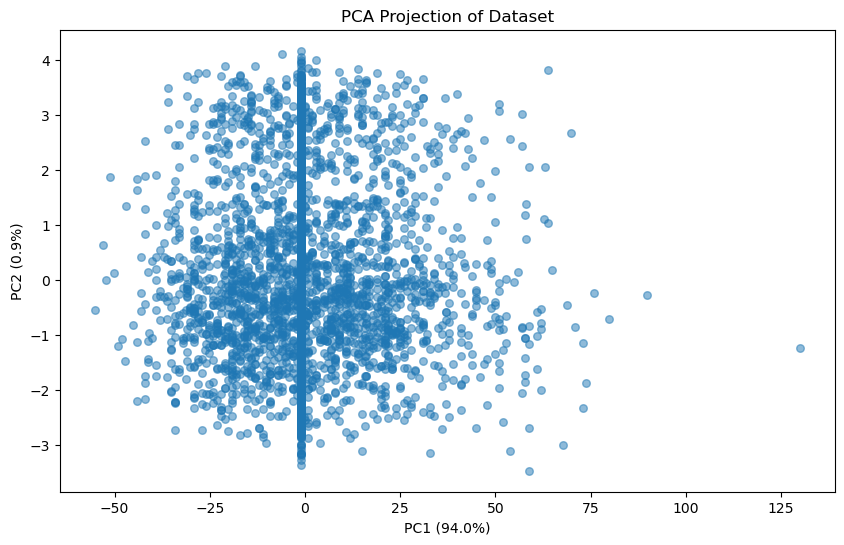

In [44]:
# PCA for 2D/3D visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"Variance explained by first 2 components: {pca.explained_variance_ratio_.sum():.2%}")

# Visualization
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5, s=30)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.title('PCA Projection of Dataset')
plt.show()

## 3. KMEANS CLUSTERING
### 3.1 Determining Optimal Number of Clusters
#### Elbow Method

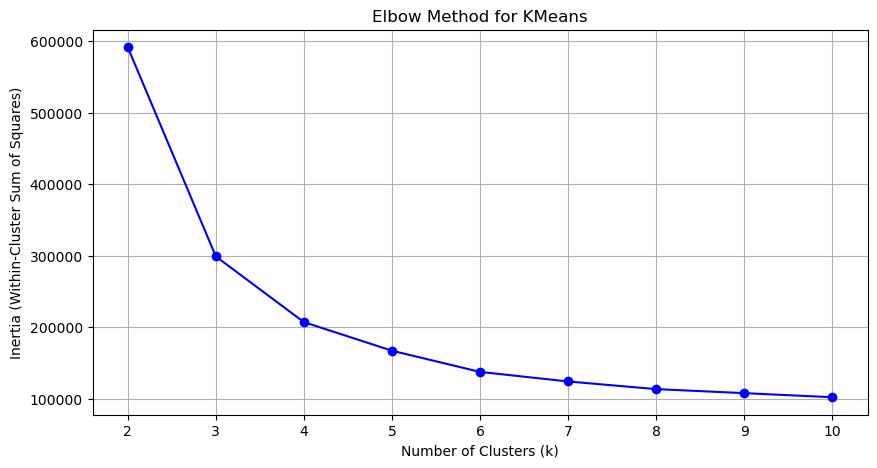

In [45]:
# Calculate inertia for different k
inertias = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Number of Clusters (k)')

plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.title('Elbow Method for KMeans')
plt.grid(True)
plt.show()

**Interpretation:** Look for the "elbow" where the curve changes slope

#### Silhouette Score

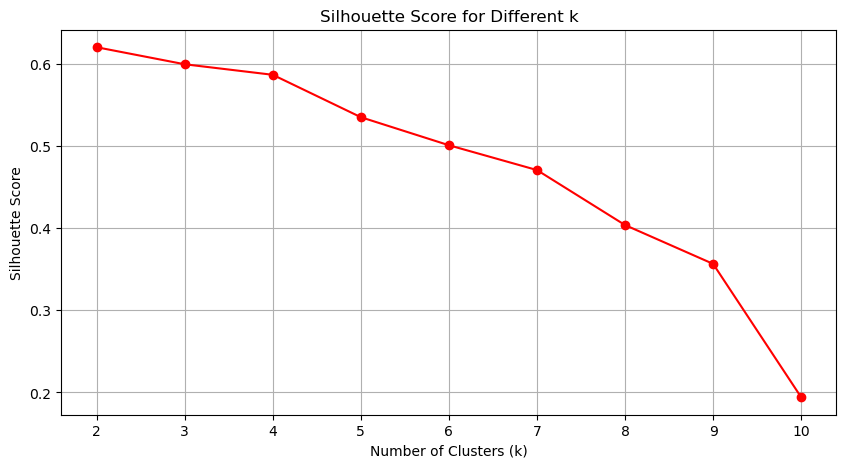

Silhouette scores:
k=2: 0.6202
k=3: 0.5995
k=4: 0.5867
k=5: 0.5351
k=6: 0.5009
k=7: 0.4707
k=8: 0.4038
k=9: 0.3565
k=10: 0.1942


In [46]:
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(10, 5))
plt.plot(K_range, silhouette_scores, 'ro-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Different k')
plt.grid(True)
plt.show()

print("Silhouette scores:")
for k, score in zip(K_range, silhouette_scores):
    print(f"k={k}: {score:.4f}")

**Interpretation:** Higher values indicate better clustering (range: -1 to 1)

### 3.2 Applying KMeans with Optimal k

In [47]:
# Choose k based on previous methods (e.g., k=3)
optimal_k = 2

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Add labels to dataframe
df['kmeans_cluster'] = kmeans_labels

print(f"KMeans cluster distribution:")
print(df['kmeans_cluster'].value_counts().sort_index())

KMeans cluster distribution:
kmeans_cluster
0    4053
1     708
Name: count, dtype: int64


### 3.3 Evaluation and Interpretation

In [48]:
# Metrics
silhouette_kmeans = silhouette_score(X_scaled, kmeans_labels)
davies_bouldin_kmeans = davies_bouldin_score(X_scaled, kmeans_labels)
calinski_kmeans = calinski_harabasz_score(X_scaled, kmeans_labels)

print(f"\nKMeans Metrics (k={optimal_k}):")
print(f"Silhouette Score: {silhouette_kmeans:.4f}")
print(f"Davies-Bouldin Index: {davies_bouldin_kmeans:.4f} (lower is better)")
print(f"Calinski-Harabasz Index: {calinski_kmeans:.4f} (higher is better)")


KMeans Metrics (k=2):
Silhouette Score: 0.6202
Davies-Bouldin Index: 0.6191 (lower is better)
Calinski-Harabasz Index: 5109.4512 (higher is better)


### Clustering Visualization with UMAP

/home/gabriele/miniconda3/envs/DADH/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


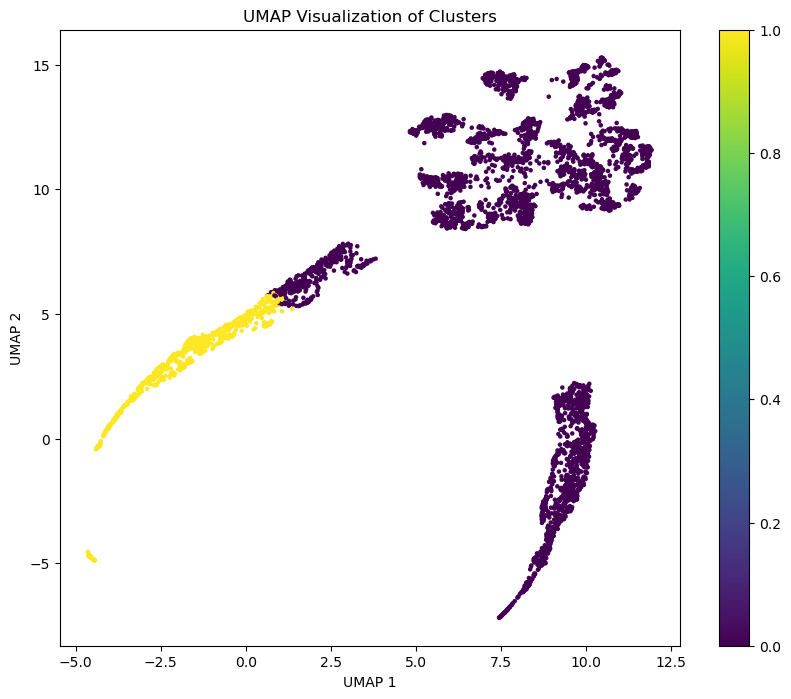

In [49]:
import umap

# Configura UMAP per la visualizzazione
umap_reducer = umap.UMAP(
    n_neighbors=15,      
    min_dist=0.1,        
    n_components=2,      
    metric='euclidean',  
    random_state=42
)

umap_embedding = umap_reducer.fit_transform(X_scaled)

# Visualizza i cluster
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    umap_embedding[:, 0], 
    umap_embedding[:, 1], 
    c=kmeans.labels_, 
    cmap='viridis',
    s=5
)
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title('UMAP Visualization of Clusters')
plt.colorbar(scatter)
plt.show()


In [50]:
from sklearn.neighbors import LocalOutlierFactor

outlier_detector = LocalOutlierFactor(contamination=0.01)  # 1% outliers
outlier_labels = outlier_detector.fit_predict(umap_embedding)

In [51]:
outlier_mask = outlier_labels == -1
n_outliers = np.sum(outlier_mask)

print(f"outliers percentage: {n_outliers/len(outlier_labels)*100:.2f}%")
outlier_indices = np.where(outlier_mask)[0]
print(f"outliers indexes: {outlier_indices}")

outliers percentage: 1.01%
outliers indexes: [  98  207  240  531  609  711 1331 1478 1567 1640 1646 1647 1753 1783
 1930 1940 1944 2132 2150 2168 2184 2288 2309 2314 2387 2426 2449 2540
 2555 2625 2688 2722 2780 3348 3537 3573 3594 3824 3857 3869 3899 3991
 4028 4065 4099 4259 4427 4646]


## 4. DBSCAN CLUSTERING
### 4.1 Determining eps and min_samples Parameters
#### K-Distance Graph for eps

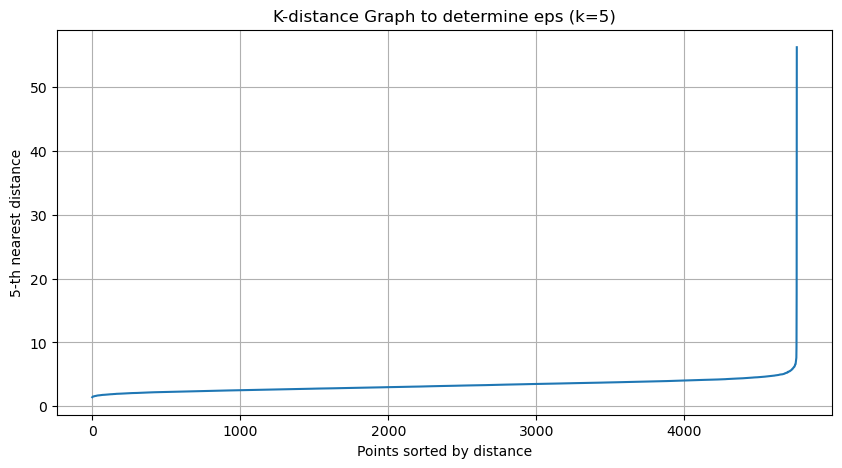

In [52]:
from sklearn.neighbors import NearestNeighbors

# Calculate k-distance (k = recommended min_samples)
k = 5  # try different values: 4, 5, 10
neighbors = NearestNeighbors(n_neighbors=k)
neighbors.fit(X_scaled)
distances, indices = neighbors.kneighbors(X_scaled)

# Sort distances for k-th nearest neighbor
distances = np.sort(distances[:, k-1], axis=0)

plt.figure(figsize=(10, 5))
plt.plot(distances)
plt.xlabel('Points sorted by distance')
plt.ylabel(f'{k}-th nearest distance')
plt.title(f'K-distance Graph to determine eps (k={k})')
plt.grid(True)
plt.show()

# Hint: look for the "knee" point in the curve

**Interpretation:** The point where the curve has a "knee" suggests a good value for eps

### 4.2 Grid Search for Optimal Parameters

In [53]:
# Try different combinations
eps_values = [2.0, 2.5, 3.0, 3.25, 3.5, 3.75, 4.0]
min_samples_values = [5, 10, 15, 20, 25, 30]

results = []

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_scaled)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        
        if n_clusters > 1:
            silhouette = silhouette_score(X_scaled[labels != -1], labels[labels != -1])
        else:
            silhouette = -1
        
        results.append({
            'eps': eps,
            'min_samples': min_samples,
            'n_clusters': n_clusters,
            'n_noise': n_noise,
            'noise_ratio': n_noise / len(labels),
            'silhouette': silhouette
        })

results_df = pd.DataFrame(results)

# Metodo 1: Basato solo su silhouette score
best_params_silhouette = results_df.loc[results_df['silhouette'].idxmax()]
print("Best parameters (silhouette):")
print(f"  eps: {best_params_silhouette['eps']}")
print(f"  min_samples: {best_params_silhouette['min_samples']}")
print(f"  silhouette: {best_params_silhouette['silhouette']:.4f}")
print(f"  n_clusters: {int(best_params_silhouette['n_clusters'])}")
print(f"  noise_ratio: {best_params_silhouette['noise_ratio']:.2%}\n")

filtered_results = results_df[results_df['noise_ratio'] < 0.10]
if len(filtered_results) > 0:
    best_params_filtered = filtered_results.loc[filtered_results['silhouette'].idxmax()]
    print("Best parameters (silhouette + noise < 10%):")
    print(f"  eps: {best_params_filtered['eps']}")
    print(f"  min_samples: {best_params_filtered['min_samples']}")
    print(f"  silhouette: {best_params_filtered['silhouette']:.4f}\n")

optimal_eps = best_params_filtered['eps']
optimal_min_samples = int(best_params_filtered['min_samples'])
print(f"Selected DBSCAN parameters: eps={optimal_eps}, min_samples={optimal_min_samples}")

Best parameters (silhouette):
  eps: 3.75
  min_samples: 30.0
  silhouette: 0.7014
  n_clusters: 3
  noise_ratio: 42.28%

Best parameters (silhouette + noise < 10%):
  eps: 4.0
  min_samples: 5.0
  silhouette: 0.4986

Selected DBSCAN parameters: eps=4.0, min_samples=5


### 4.3 Applying DBSCAN with Optimal Parameters

In [54]:
dbscan = DBSCAN(eps=optimal_eps, min_samples=optimal_min_samples)
dbscan_labels = dbscan.fit_predict(X_scaled)

df['dbscan_cluster'] = dbscan_labels

n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_dbscan = list(dbscan_labels).count(-1)

print(f"\nDBSCAN (eps={optimal_eps}, min_samples={optimal_min_samples}):")
print(f"Number of clusters: {n_clusters_dbscan}")
print(f"Noise points: {n_noise_dbscan} ({n_noise_dbscan/len(dbscan_labels)*100:.1f}%)")
print(f"\nCluster distribution:")
print(pd.Series(dbscan_labels).value_counts().sort_index())


DBSCAN (eps=4.0, min_samples=5):
Number of clusters: 4
Noise points: 382 (8.0%)

Cluster distribution:
-1     382
 0    4351
 1      13
 2      10
 3       5
Name: count, dtype: int64


### 4.4 Evaluation and Visualization

In [55]:
# Metrics (excluding noise)
if n_clusters_dbscan > 1:
    non_noise = dbscan_labels != -1
    silhouette_dbscan = silhouette_score(X_scaled[non_noise], dbscan_labels[non_noise])
    davies_bouldin_dbscan = davies_bouldin_score(X_scaled[non_noise], dbscan_labels[non_noise])
    calinski_dbscan = calinski_harabasz_score(X_scaled[non_noise], dbscan_labels[non_noise])

    print(f"\nDBSCAN Metrics:")
    print(f"Silhouette Score: {silhouette_dbscan:.4f}")
    print(f"Davies-Bouldin Index: {davies_bouldin_dbscan:.4f}")
    print(f"Calinski-Harabasz Index: {calinski_dbscan:.4f}")


DBSCAN Metrics:
Silhouette Score: 0.4986
Davies-Bouldin Index: 0.5217
Calinski-Harabasz Index: 122.6585


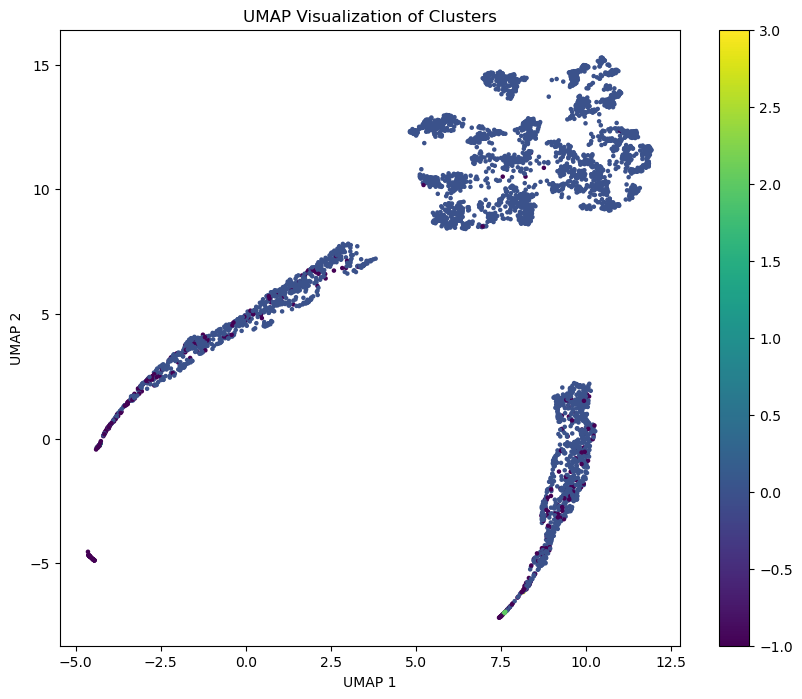

In [56]:
# Visualizza i cluster
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    umap_embedding[:, 0], 
    umap_embedding[:, 1], 
    c=dbscan_labels, 
    cmap='viridis',
    s=5
)
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title('UMAP Visualization of Clusters')
plt.colorbar(scatter)
plt.show()

## 5. HIERARCHICAL CLUSTERING
### 5.1 Choosing Linkage Method

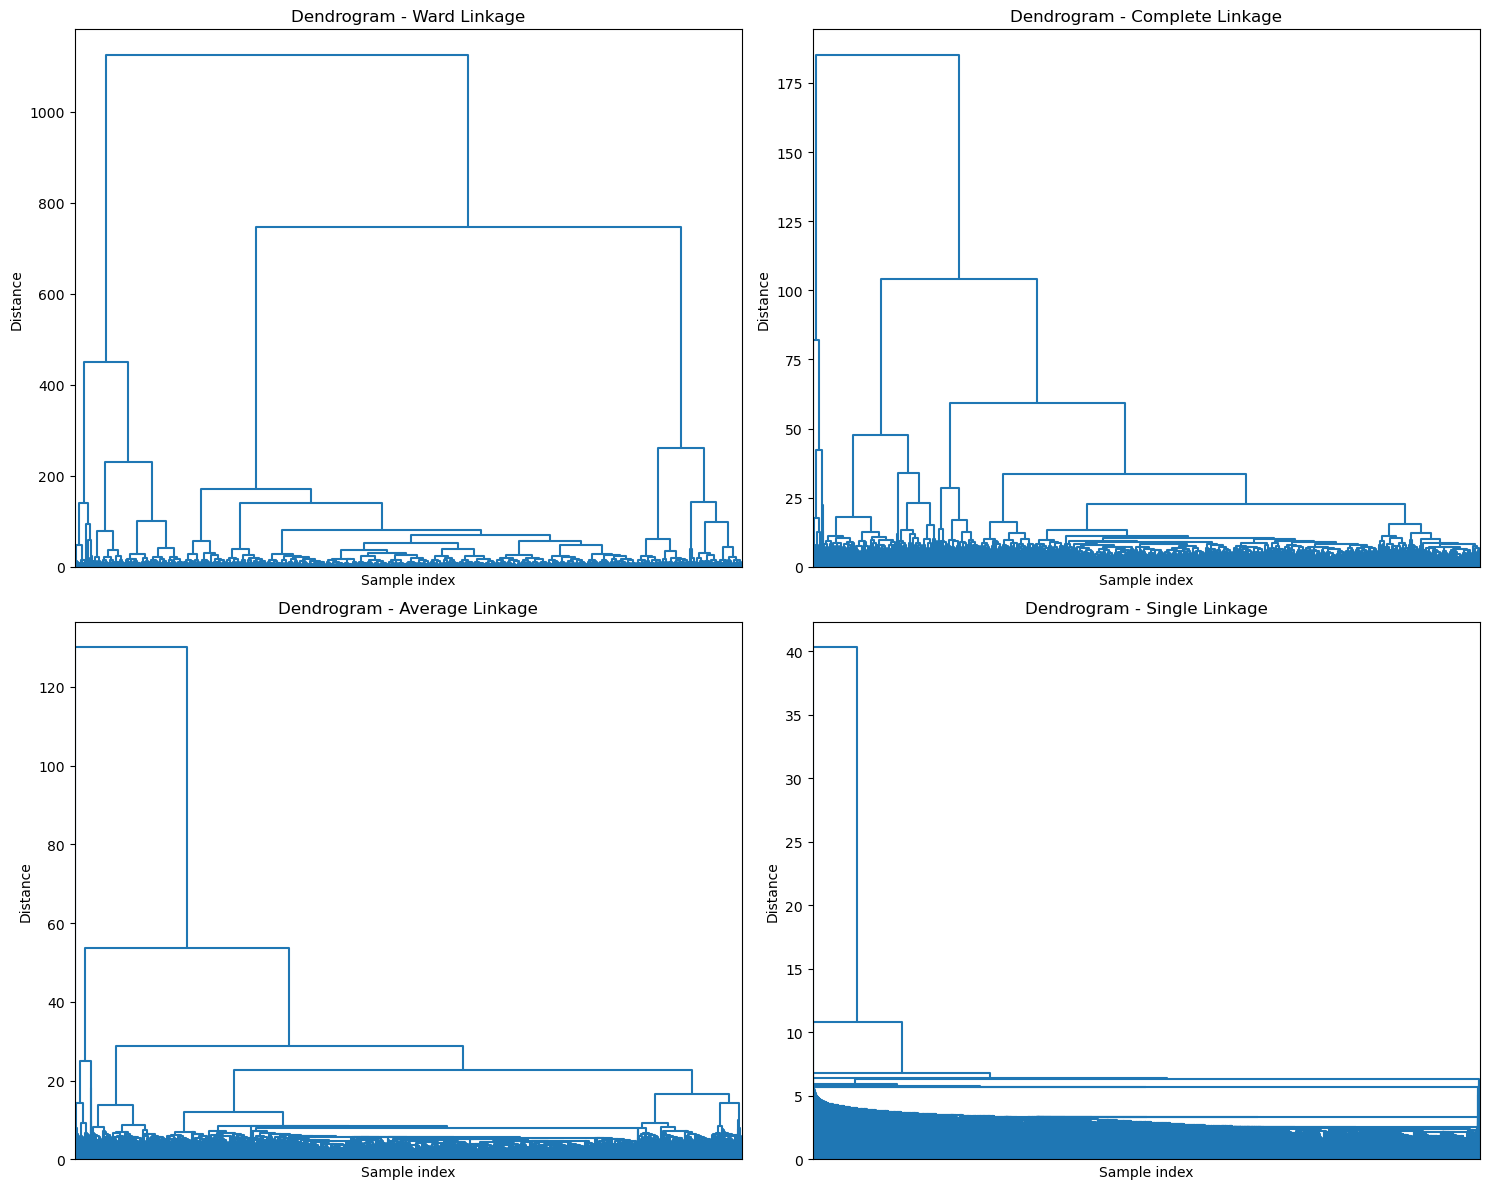

In [57]:
# Try different linkage methods
linkage_methods = ['ward', 'complete', 'average', 'single']

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.ravel()

for idx, method in enumerate(linkage_methods):
    # Calculate linkage
    Z = linkage(X_scaled, method=method)

    # Dendrogram
    axes[idx].set_title(f'Dendrogram - {method.capitalize()} Linkage')
    dendrogram(Z, ax=axes[idx], no_labels=True, color_threshold=0)
    axes[idx].set_xlabel('Sample index')
    axes[idx].set_ylabel('Distance')

plt.tight_layout()
plt.show()

**Interpretation of methods:**
- **Ward**: minimizes intra-cluster variance (best for spherical clusters)
- **Complete**: maximum distance between clusters (sensitive to outliers)
- **Average**: average of distances (compromise)
- **Single**: minimum distance (can create chains)

### 5.2 Determining Number of Clusters

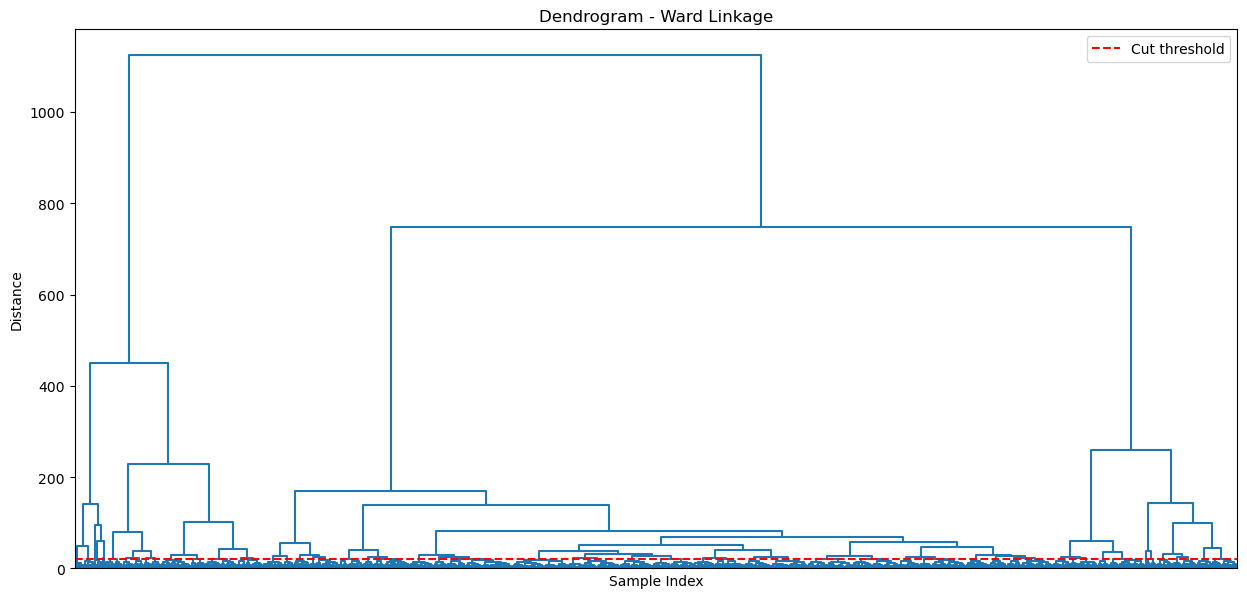

n_clusters=2: silhouette=0.6072
n_clusters=3: silhouette=0.5882
n_clusters=4: silhouette=0.5953
n_clusters=5: silhouette=0.5030
n_clusters=6: silhouette=0.4820
n_clusters=7: silhouette=0.3182
n_clusters=8: silhouette=0.3142
n_clusters=9: silhouette=0.3120
n_clusters=10: silhouette=0.2990


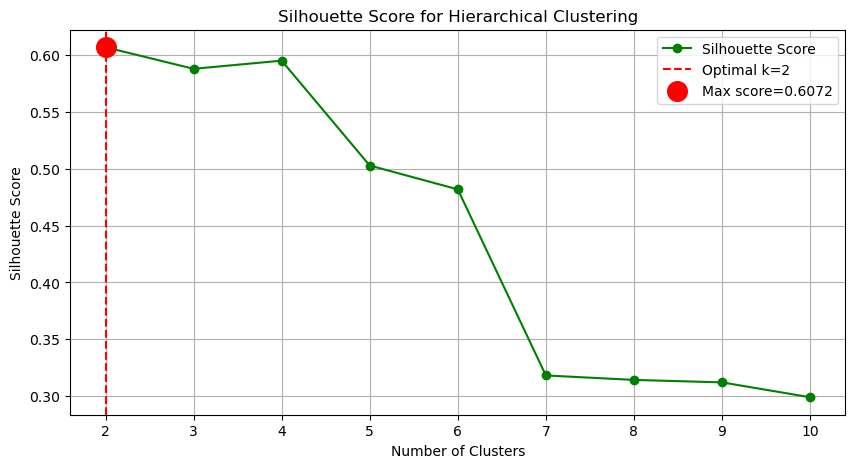

In [58]:
# Use Ward
Z = linkage(X_scaled, method='ward')

# Dendrogram with cut line
plt.figure(figsize=(15, 7))
dendrogram(Z, no_labels=True, color_threshold=0)
plt.title('Dendrogram - Ward Linkage')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.axhline(y=20, color='r', linestyle='--', label='Cut threshold')
plt.legend()
plt.show()

from scipy.cluster.hierarchy import fcluster

n_clusters_range = range(2, 11)
silhouette_scores_hc = []

for n_clusters in n_clusters_range:
    hc_labels = fcluster(Z, n_clusters, criterion='maxclust')
    score = silhouette_score(X_scaled, hc_labels)
    silhouette_scores_hc.append(score)
    print(f"n_clusters={n_clusters}: silhouette={score:.4f}")

optimal_k_hc = n_clusters_range[np.argmax(silhouette_scores_hc)]
max_silhouette_hc = max(silhouette_scores_hc)

plt.figure(figsize=(10, 5))
plt.plot(n_clusters_range, silhouette_scores_hc, 'go-', label='Silhouette Score')
plt.axvline(x=optimal_k_hc, color='r', linestyle='--', 
            label=f'Optimal k={optimal_k_hc}')
plt.scatter(optimal_k_hc, max_silhouette_hc, color='red', s=200, 
            zorder=5, label=f'Max score={max_silhouette_hc:.4f}')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Hierarchical Clustering')
plt.legend()
plt.grid(True)
plt.show()


### 5.3 Applying Hierarchical Clustering

In [59]:
# Method 1: using fcluster
hc_labels_fcluster = fcluster(Z, optimal_k_hc, criterion='maxclust') - 1  # -1 to start from 0

print("Cluster distribution:")
unique, counts = np.unique(hc_labels_fcluster, return_counts=True)
for cluster, count in zip(unique, counts):
    print(f"  Cluster {cluster}: {count} patients ({count/len(hc_labels_fcluster)*100:.1f}%)")

Cluster distribution:
  Cluster 0: 772 patients (16.2%)
  Cluster 1: 3989 patients (83.8%)


In [60]:
# Method 2: using AgglomerativeClustering (more flexible)
hierarchical = AgglomerativeClustering(n_clusters=optimal_k_hc, linkage='ward')
hc_labels = hierarchical.fit_predict(X_scaled)

df['hierarchical_cluster'] = hc_labels

print(f"\nHierarchical cluster distribution:")
print(df['hierarchical_cluster'].value_counts().sort_index())


Hierarchical cluster distribution:
hierarchical_cluster
0    3989
1     772
Name: count, dtype: int64


### 5.4 Evaluation and Interpretation

In [61]:
# Metrics
silhouette_hc = silhouette_score(X_scaled, hc_labels)
davies_bouldin_hc = davies_bouldin_score(X_scaled, hc_labels)
calinski_hc = calinski_harabasz_score(X_scaled, hc_labels)

print(f"\nHierarchical Clustering Metrics (n={optimal_k_hc}):")
print(f"Silhouette Score: {silhouette_hc:.4f}")
print(f"Davies-Bouldin Index: {davies_bouldin_hc:.4f}")
print(f"Calinski-Harabasz Index: {calinski_hc:.4f}")


Hierarchical Clustering Metrics (n=2):
Silhouette Score: 0.6072
Davies-Bouldin Index: 0.6466
Calinski-Harabasz Index: 5064.4084


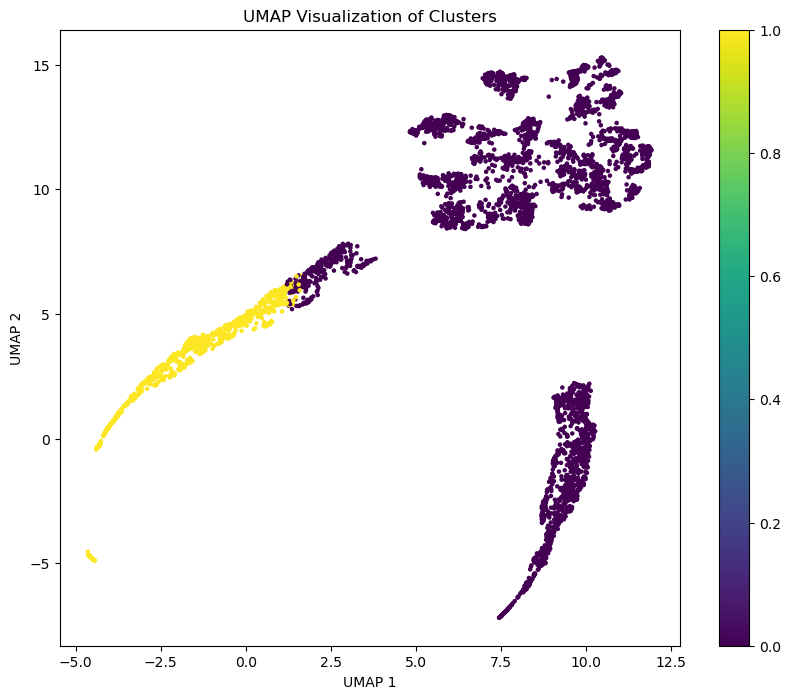

In [62]:
# Visualizza i cluster
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    umap_embedding[:, 0], 
    umap_embedding[:, 1], 
    c=hc_labels, 
    cmap='viridis',
    s=5
)
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title('UMAP Visualization of Clusters')
plt.colorbar(scatter)
plt.show()

## 6. COMPARISON BETWEEN METHODS
### 6.1 Metrics Comparison

In [63]:
# Comparative table
comparison = pd.DataFrame({
    'Method': ['KMeans', 'DBSCAN', 'Hierarchical'],
    'N_Clusters': [optimal_k, n_clusters_dbscan, optimal_k_hc],
    'Silhouette': [silhouette_kmeans, silhouette_dbscan, silhouette_hc],
    'Davies-Bouldin': [davies_bouldin_kmeans, davies_bouldin_dbscan, davies_bouldin_hc],
    'Calinski-Harabasz': [calinski_kmeans, calinski_dbscan, calinski_hc]
})

print(comparison.to_string(index=False))

      Method  N_Clusters  Silhouette  Davies-Bouldin  Calinski-Harabasz
      KMeans           2    0.620232        0.619138        5109.451241
      DBSCAN           4    0.498585        0.521747         122.658465
Hierarchical           2    0.607172        0.646591        5064.408372


### 6.2 Overlap Analysis

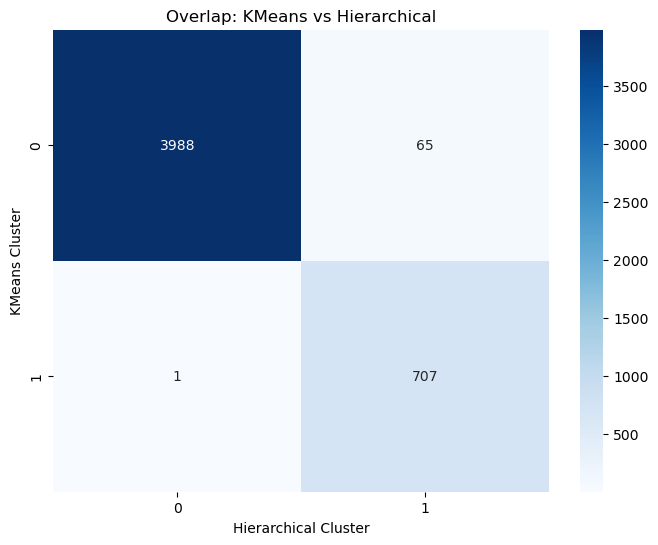


Adjusted Rand Index (KMeans vs Hierarchical): 0.9294
Normalized Mutual Information: 0.8607


In [64]:
# Confusion matrix between methods
from sklearn.metrics import confusion_matrix

# KMeans vs Hierarchical
cm_km_hc = confusion_matrix(df['kmeans_cluster'], df['hierarchical_cluster'])
plt.figure(figsize=(8, 6))
sns.heatmap(cm_km_hc, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Hierarchical Cluster')
plt.ylabel('KMeans Cluster')
plt.title('Overlap: KMeans vs Hierarchical')
plt.show()

# Agreement between methods
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

ari_km_hc = adjusted_rand_score(df['kmeans_cluster'], df['hierarchical_cluster'])
nmi_km_hc = normalized_mutual_info_score(df['kmeans_cluster'], df['hierarchical_cluster'])

print(f"\nAdjusted Rand Index (KMeans vs Hierarchical): {ari_km_hc:.4f}")
print(f"Normalized Mutual Information: {nmi_km_hc:.4f}")

### 6.3 Comparative Visualization

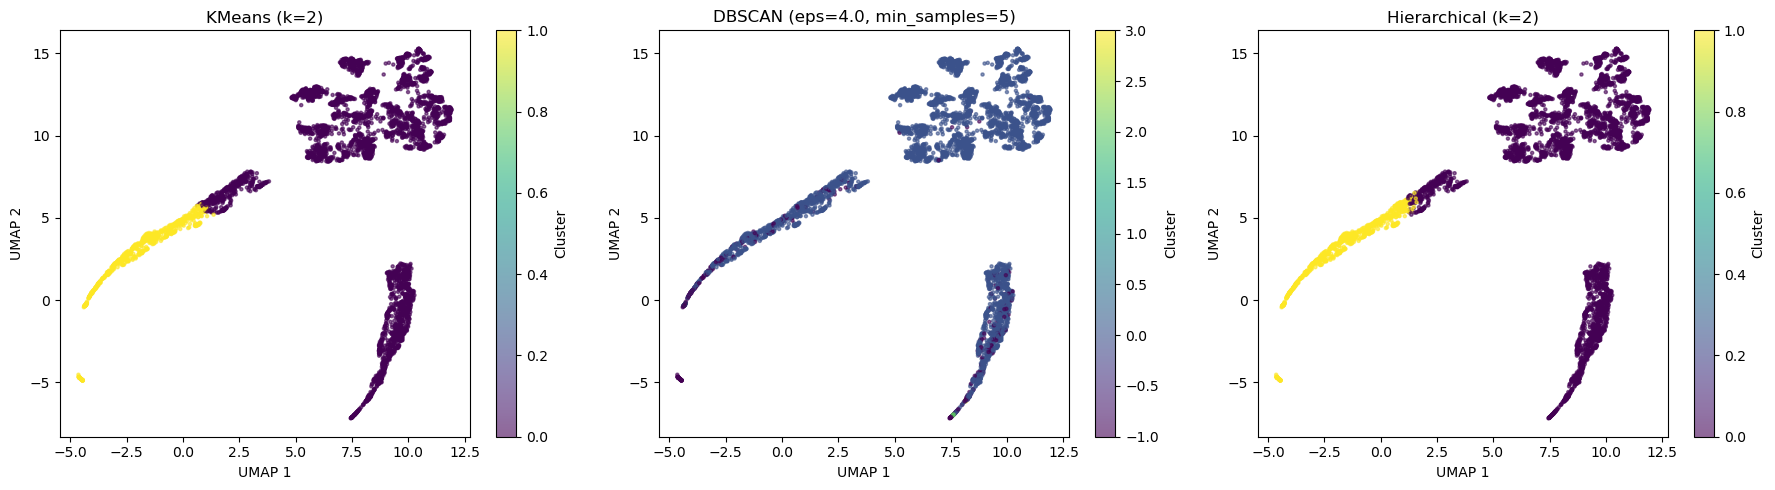

In [65]:
# Side-by-side plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# KMeans
scatter1 = axes[0].scatter(
    umap_embedding[:, 0], 
    umap_embedding[:, 1], 
    c=df['kmeans_cluster'], 
    cmap='viridis',
    s=5,
    alpha=0.6
)
axes[0].set_xlabel('UMAP 1')
axes[0].set_ylabel('UMAP 2')
axes[0].set_title(f'KMeans (k={optimal_k})')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# DBSCAN
scatter2 = axes[1].scatter(
    umap_embedding[:, 0], 
    umap_embedding[:, 1], 
    c=df['dbscan_cluster'], 
    cmap='viridis',
    s=5,
    alpha=0.6
)
axes[1].set_xlabel('UMAP 1')
axes[1].set_ylabel('UMAP 2')
axes[1].set_title(f'DBSCAN (eps={optimal_eps}, min_samples={optimal_min_samples})')
plt.colorbar(scatter2, ax=axes[1], label='Cluster')

# Hierarchical
scatter3 = axes[2].scatter(
    umap_embedding[:, 0], 
    umap_embedding[:, 1], 
    c=df['hierarchical_cluster'], 
    cmap='viridis',
    s=5,
    alpha=0.6
)
axes[2].set_xlabel('UMAP 1')
axes[2].set_ylabel('UMAP 2')
axes[2].set_title(f'Hierarchical (k={optimal_k_hc})')
plt.colorbar(scatter3, ax=axes[2], label='Cluster')

plt.tight_layout()
plt.show()


## 7. CLINICAL INTERPRETATION OF CLUSTERS
### 7.1 Detailed Profile for Chosen Method

In [66]:
# # Use method with best metrics (e.g., KMeans)
# best_method = 'kmeans_cluster'

# # Statistics per cluster
# cluster_stats = df.groupby(best_method).agg(
#     # Cardiac features
#     valvular_mean=('valvular_disease_score', 'mean'),
#     valvular_std=('valvular_disease_score', 'std'),
#     cardiac_remod_mean=('cardiac_remodeling_score', 'mean'),
#     cardiac_remod_std=('cardiac_remodeling_score', 'std'),
#     # Respiratory
#     respiratory_mean=('respiratory_distress_score', 'mean'),
#     respiratory_std=('respiratory_distress_score', 'std'),
#     # Clinical activity
#     tests_mean=('total_tests', 'mean'),
#     tests_std=('total_tests', 'std'),
#     procedures_mean=('total_procedures', 'mean'),
#     procedures_std=('total_procedures', 'std'),
#     # Demographics
#     gender_mode=('gender', lambda x: x.value_counts().idxmax()),
#     male_pct=('gender', lambda x: (x == 1).sum() / len(x) * 100)
# )

# print("\nClinical Profile of Clusters:")
# print(cluster_stats)

# # Heatmap of mean features
# cluster_means = df.groupby(best_method)[features_for_clustering.columns].mean()
# plt.figure(figsize=(12, 8))
# sns.heatmap(cluster_means.T, annot=True, fmt='.2f', cmap='RdYlGn_r', center=0)
# plt.xlabel('Cluster')
# plt.ylabel('Feature')
# plt.title('Average Feature Profile per Cluster')
# plt.tight_layout()
# plt.show()

### 7.2 Cluster Characterization

In [67]:
# Identify distinctive features for each cluster
for cluster_id in sorted(df[best_method].unique()):
    if cluster_id == -1:  # skip noise if present
        continue

    cluster_data = df[df[best_method] == cluster_id][features_for_clustering.columns]
    other_data = df[df[best_method] != cluster_id][features_for_clustering.columns]

    print(f"\n{'='*80}")
    print(f"CLUSTER {cluster_id} - N={len(cluster_data)} patients")
    print('='*80)

    # Features with greatest difference compared to other clusters
    mean_diff = (cluster_data.mean() - other_data.mean()).abs().sort_values(ascending=False)

    print("\nTop 5 distinctive features:")
    for feature in mean_diff.head(5).index:
        cluster_mean = cluster_data[feature].mean()
        overall_mean = other_data[feature].mean()
        diff_pct = ((cluster_mean - overall_mean) / overall_mean * 100) if overall_mean != 0 else 0
        print(f"  {feature}: {cluster_mean:.3f} vs {overall_mean:.3f} ({diff_pct:+.1f}%)")

NameError: name 'best_method' is not defined

## 8. RECOMMENDATIONS AND CONCLUSIONS

### 8.1 Which Method to Choose?

**KMeans:**
- ✅ Fast, scalable
- ✅ Excellent for spherical and well-separated clusters
- ❌ Requires specifying k a priori
- ❌ Sensitive to outliers

**DBSCAN:**
- ✅ Discovers clusters of arbitrary shape
- ✅ Automatically identifies outliers
- ❌ Difficult to find optimal parameters
- ❌ Problems with varying densities

**Hierarchical:**
- ✅ Does not require k a priori
- ✅ Visualization via dendrogram
- ❌ Computationally expensive for large datasets
- ❌ Merge decisions are irreversible

### 8.2 Best Practices

In [ ]:
# # Save results
# df.to_csv('patient_profiles_clustered.csv', index=False)

# # Save optimal parameters
# import json

# clustering_params = {
#     'kmeans': {'n_clusters': optimal_k, 'silhouette': float(silhouette_kmeans)},
#     'dbscan': {'eps': optimal_eps, 'min_samples': optimal_min_samples, 
#                'silhouette': float(silhouette_dbscan)},
#     'hierarchical': {'n_clusters': optimal_n_clusters, 'linkage': 'ward',
#                     'silhouette': float(silhouette_hc)}
# }

# with open('clustering_parameters.json', 'w') as f:
#     json.dump(clustering_params, f, indent=2)

# print("\nAnalysis completed! Files saved:")
# print("- patient_profiles_clustered.csv")
# print("- clustering_parameters.json")

## KEY POINTS TO REMEMBER

1. **Preprocessing is crucial**: Always standardize for distance-based methods
2. **Multiple validation**: Use multiple metrics (Silhouette, Davies-Bouldin, Calinski-Harabasz)
3. **Visualization**: PCA helps understand structure, but does not replace complete analysis
4. **Interpretation**: Clusters must make sense in clinical context
5. **Robustness**: Try clustering with different feature subsets
6. **Documentation**: Always record parameters and metrics for reproducibility